In [ ]:
from lcapy import Circuit

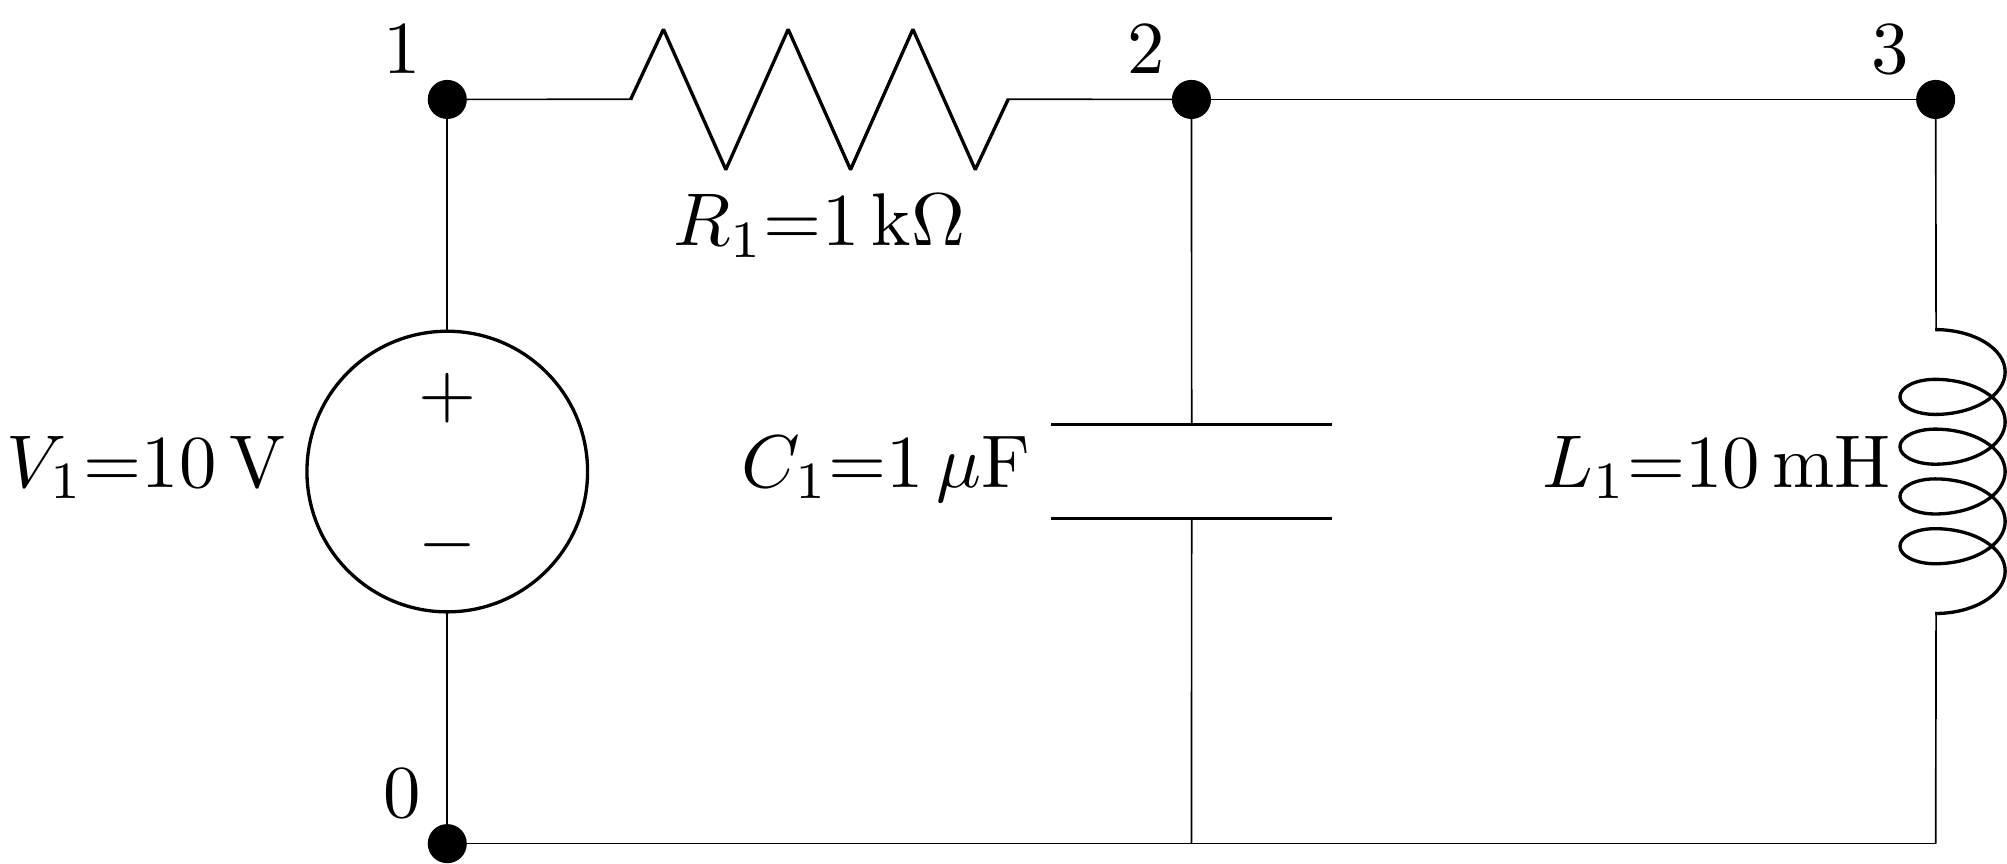

<IPython.core.display.Math object>

        1000⋅s         
───────────────────────
 2                     
s  + 1000⋅s + 100000000

'The poles are: '

'The zeros are: '

<IPython.core.display.Math object>

<IPython.core.display.Math object>

     2                 
    s  + 100000000     
───────────────────────
 2                     
s  + 1000⋅s + 100000000

'The poles are: '

'The zeros are: '

<IPython.core.display.Math object>

         1000⋅ⅉ⋅ω          
───────────────────────────
   2                       
- ω  + 1000⋅ⅉ⋅ω + 100000000

        2                  
     - ω  + 100000000      
───────────────────────────
   2                       
- ω  + 1000⋅ⅉ⋅ω + 100000000

In [24]:
from lcapy import Circuit
from lcapy import j, omega
from IPython.display import display, Math

c = Circuit("""
V1 1 0 {10}; down
R1 1 2 1k; right

C1 2 0_2 1u; down
W 0 0_2; right

W 2 3; right
L1 3 0_3 10m; down
W 0_2 0_3; right
""")
c.draw(scale=1.8, node_spacing=3.5, cpt_size=2.2)
#c.draw()

H = c.transfer(1,0,2,0)
H1 = c.transfer(1,0,1,2)
display(Math("\\text{Band-pass Transfer Function}"))
display(H)
display("The poles are: ",H.poles())
display("The zeros are: ",H.zeros())

display(Math("\\text{The measured voltage of V(2)-V(0) is associated with a Band-pass filter}"))
display(Math("\\text{Band-stop Transfer Function}"))
display(H1)
display("The poles are: ",H1.poles())
display("The zeros are: ",H1.zeros())
display(Math("\\text{The measured voltage of V(2)-V(1) is associated with a Band-stop (notch) filter}"))
Hw = H.subs('s', j * omega)
Hw1 = H1.subs('s', j * omega)
display(Hw)
display(Hw1)

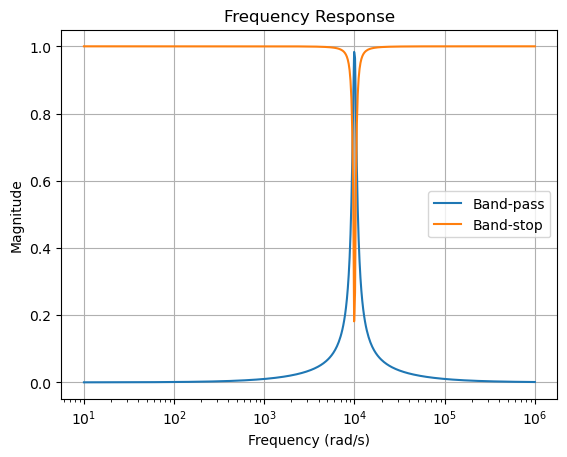

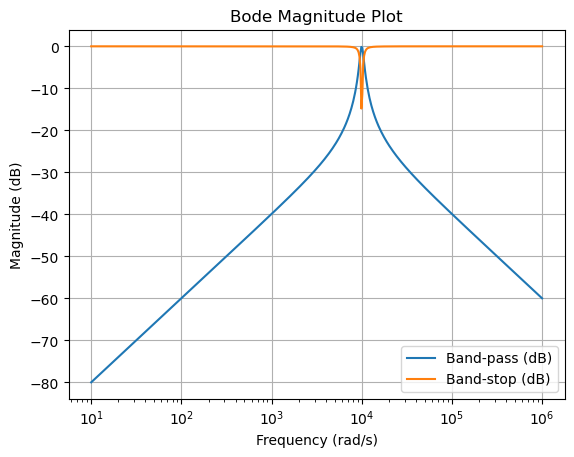

Peak frequency: 9908.136566858666


In [20]:
import numpy as np
from lcapy import j
import pandas as pd
import matplotlib.pyplot as plt


 # Frequency sweep
w_vals = np.logspace(1, 6, 500)
 # Tables to store data
H_vals = []
H1_vals = []

for w in w_vals:
    val_H  = H.subs('s', j*w).evalf()
    val_H1 = H1.subs('s', j*w).evalf()
    
    H_vals.append(abs(complex(val_H.evaluate())))
    H1_vals.append(abs(complex(val_H1.evaluate())))



df = pd.DataFrame({
    'omega (rad/s)': w_vals,
    '|H(jw)| (Band-pass)': H_vals,
    '|H1(jw)| (Band-stop)': H1_vals
})

df.head()



plt.figure()

plt.semilogx(w_vals, H_vals, label='Band-pass')
plt.semilogx(w_vals, H1_vals, label='Band-stop')

plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude')
plt.title('Frequency Response')

plt.legend()
plt.grid(True)

plt.show()

H_db = 20 * np.log10(H_vals)
H1_db = 20 * np.log10(H1_vals)

plt.figure()

plt.semilogx(w_vals, H_db, label='Band-pass (dB)')
plt.semilogx(w_vals, H1_db, label='Band-stop (dB)')

plt.xlabel('Frequency (rad/s)')
plt.ylabel('Magnitude (dB)')
plt.title('Bode Magnitude Plot')

plt.legend()
plt.grid(True)

plt.show()

import numpy as np

peak_index = np.argmax(H_vals)
print("Peak frequency:", w_vals[peak_index])

w1, w2: 9682.153059967086 10376.050197669118
Bandwidth: 693.8971377020316
Q: 14.4113579040214


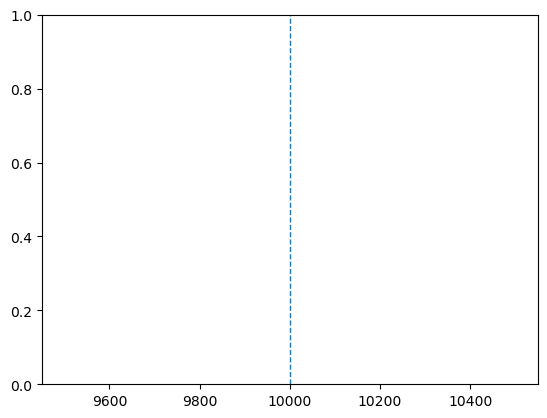

In [21]:
H_bp = np.array(H_vals)
H_bs = np.array(H1_vals)

H_bp_norm = H_bp / H_bp.max()
H_bs_norm = H_bs  # notch already tops out at ~1

eps = 1e-12
H_bp_db = 20*np.log10(np.maximum(H_bp_norm, eps))
H_bs_db = 20*np.log10(np.maximum(H_bs, eps))

w0 = 1/np.sqrt(10e-3 * 1e-6)

plt.axvline(w0, linestyle='--', linewidth=1)

target = 1/np.sqrt(2)  # -3 dB

idx = np.where(H_bp_norm >= target)[0]
w1, w2 = w_vals[idx[0]], w_vals[idx[-1]]

BW = w2 - w1
Q  = w0 / BW

print("w1, w2:", w1, w2)
print("Bandwidth:", BW)
print("Q:", Q)

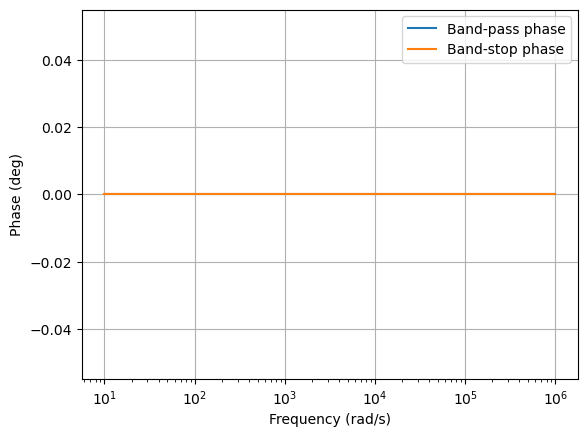

In [22]:
phase_bp = np.angle(H_bp, deg=True)
phase_bs = np.angle(H_bs, deg=True)

plt.figure()
plt.semilogx(w_vals, phase_bp, label='Band-pass phase')
plt.semilogx(w_vals, phase_bs, label='Band-stop phase')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.grid(True)
plt.legend()

In [26]:
H_vals_complex = []
H1_vals_complex = []

H_vals = []
H1_vals = []

for w in w_vals:
    val_H  = H.subs('s', j*w).evaluate()
    val_H1 = H1.subs('s', j*w).evaluate()

    val_H_c  = complex(val_H)
    val_H1_c = complex(val_H1)

    H_vals_complex.append(val_H_c)
    H1_vals_complex.append(val_H1_c)

    H_vals.append(abs(val_H_c))
    H1_vals.append(abs(val_H1_c))

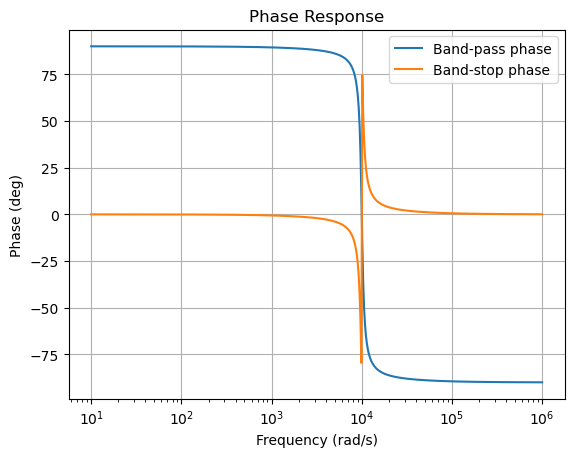

In [27]:
phase_bp = np.angle(np.array(H_vals_complex), deg=True)
phase_bs = np.angle(np.array(H1_vals_complex), deg=True)

plt.figure()
plt.semilogx(w_vals, phase_bp, label='Band-pass phase')
plt.semilogx(w_vals, phase_bs, label='Band-stop phase')
plt.xlabel('Frequency (rad/s)')
plt.ylabel('Phase (deg)')
plt.title('Phase Response')
plt.grid(True)
plt.legend()
plt.show()

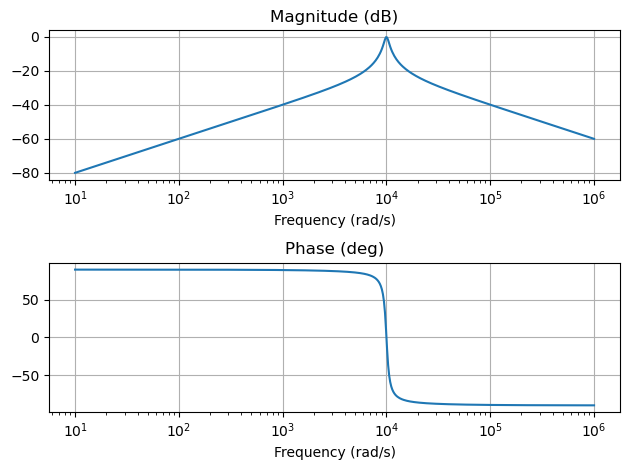

In [29]:
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.semilogx(w_vals, 20*np.log10(H_vals))
ax1.set_title("Magnitude (dB)")
ax1.set_xlabel("Frequency (rad/s)")
ax1.grid(True)

ax2.semilogx(w_vals, phase_bp)
ax2.set_title("Phase (deg)")
ax2.set_xlabel("Frequency (rad/s)")
ax2.grid(True)

plt.tight_layout()
plt.show()